# Project 1: Algorithmic trading

Algorithmic trading is the use of computer programs to automate stock trading decisions, based on available data such as share price or trading volume over different periods of time.

In this project, you will implement different trading strategies in Python, and put them to the test by evaluating their performance on simulated stock market data. This is a similar study as that done e.g. in [this paper](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0068344).

🚩 There is quite a lot of text to explain context -- to make sure you don't miss any tasks, they are marked with a little red flag (like in the tutorial sheets).

---

### Structure

You will **write a Python [package](https://docs.python.org/3/tutorial/modules.html#packages)** called `trading`. A package is basically a folder containing `.py` files (*modules*) with some function definitions inside -- you should see that this folder is already created in your repo. The package contain five [modules](https://docs.python.org/3/tutorial/modules.html#modules): `data.py`, `process.py`, `indicators.py`, `strategy.py`, and `performance.py`, as well as an initialisation script `__init__.py`.

You will write functions inside each module to perform different tasks. Then, you will use your custom modules in this Jupyter notebook to run your simulations. Just like for any other package, you will need to import it in the notebook first. For example, to use the function `create_portfolio()` in the `process.py` module, you can use

```python
import trading.process as proc
portfolio = proc.create_portfolio(...
```

The script `__init__.py` is just here to indicate that `trading` is a Python package, and not just a simple folder. It can remain empty.

Note that if, for example, your functions in your module `strategy.py` need any other modules to work (e.g. Numpy, pyplot, or one of your other custom modules...), you'll need to import them at the start of `strategy.py`. You'll also need to import them again if the code you use here (in the notebook) requires it.

Each task will give more detailed instructions of what should go in each module.

**Note:** if you change anything in one of your modules, even if you run the `import trading....` command again in the notebook, this **will not update** with the new version of your module. Instead, **restart the kernel** and import the module again to use your latest changes (Kernel > Restart in the toolbar).

---
You are tasked with writing the code to generate the simulated stock market data, for a number of stocks. Here is the brief for this part of the project:

> Generate simulated stock prices over a period of time, for a given number of companies, given share price at initial date, and volatility. Return data in a NumPy array, each column representing the price history for 1 company, and each row representing the share prices for all the stocks at a given date.
>
> The time increment is **1 day**, and share prices are given as the **closing price** each day.
>
> We assume that the [random walk hypothesis](https://en.wikipedia.org/wiki/Random_walk_hypothesis) holds. This means that the share price $p_t$ on a given day ($t>0$) and for a given company is normally given by
>
> $$
p_{t} = p_{t-1} + \Delta p_t,
$$
>
> where $\Delta p_t \sim N(0, \sigma^2)$ is the share price increment each day, normally distributed with mean $0$ and standard deviation $\sigma$. We take $\sigma$ to represent the inherent **volatility** of the stock.
>
> Whenever a share price dips to zero, we consider the company closed, and the daily share prices starting on that day until the end of the simulation should be set to `NaN`.
>
> We also model randomly occurring **important news** (e.g. political turmoil, a natural disaster, a new product announcement...), which have a positive or negative impact on share price over a number of days. This impact is modelled as a temporary **drift** $d$ in share price increments, positive or negative, with more or less magnitude depending on the volatility of the stock price.
> - Every day, there is a 1% chance of such an event happening, and immediately starting to impact the price of a given stock.
> - To represent that the news might impact an inherently more volatile stock more significantly than a less volatile stock, the drift $d$ is proportional to $\sigma$.
> - To represent that high-impact events happen more rarely, we choose $d = m \sigma$, with $m \sim N(0, 2^2)$ -- that is, the drift is equal to $m$ standard deviations of the usual increment. This means that the event is equally likely to be positive or negative, but that, for example, the magnitude of the drift is only about 5% likely to be greater than $4\sigma$.
> - When an event occurs, its impact lasts for anywhere between 3 days and 2 weeks -- i.e. the total duration is $t_{\text{event}} \sim U\{3, 14\}$.
> - The impact of several events occurring over the same time span is cumulative.
> 
> To summarise, the share price $p_t$ on a given day ($t>0$) and for a given company is given by
>
> $$
p_t = p_{t-1} + \Delta p_t + \sum_i d_i,
$$
>
> where each $d_i$ is the drift caused by an "active" event.
>
> For example: if the current day is $t = 15$, and
> - at $t = 10$, a negative event occurred, causing a drift $d_1$ lasting $6$ days,
> - at $t = 12$, another negative event occurred, causing a drift $d_2$ lasting $12$ days,
> - at $t = 15$ (today), a positive event occurs, causing a drift $d_3$ lasting $3$ days,
>
> then the share price today is given by
>
> $$ p_{15} = p_{14} + \Delta p_{15} + d_1 + d_2 + d_3. $$
>
> And tomorrow, if no event occurs, the first negative event will cease to have an impact:
>
> $$ p_{16} = p_{15} + \Delta p_{16} + d_2 + d_3. $$

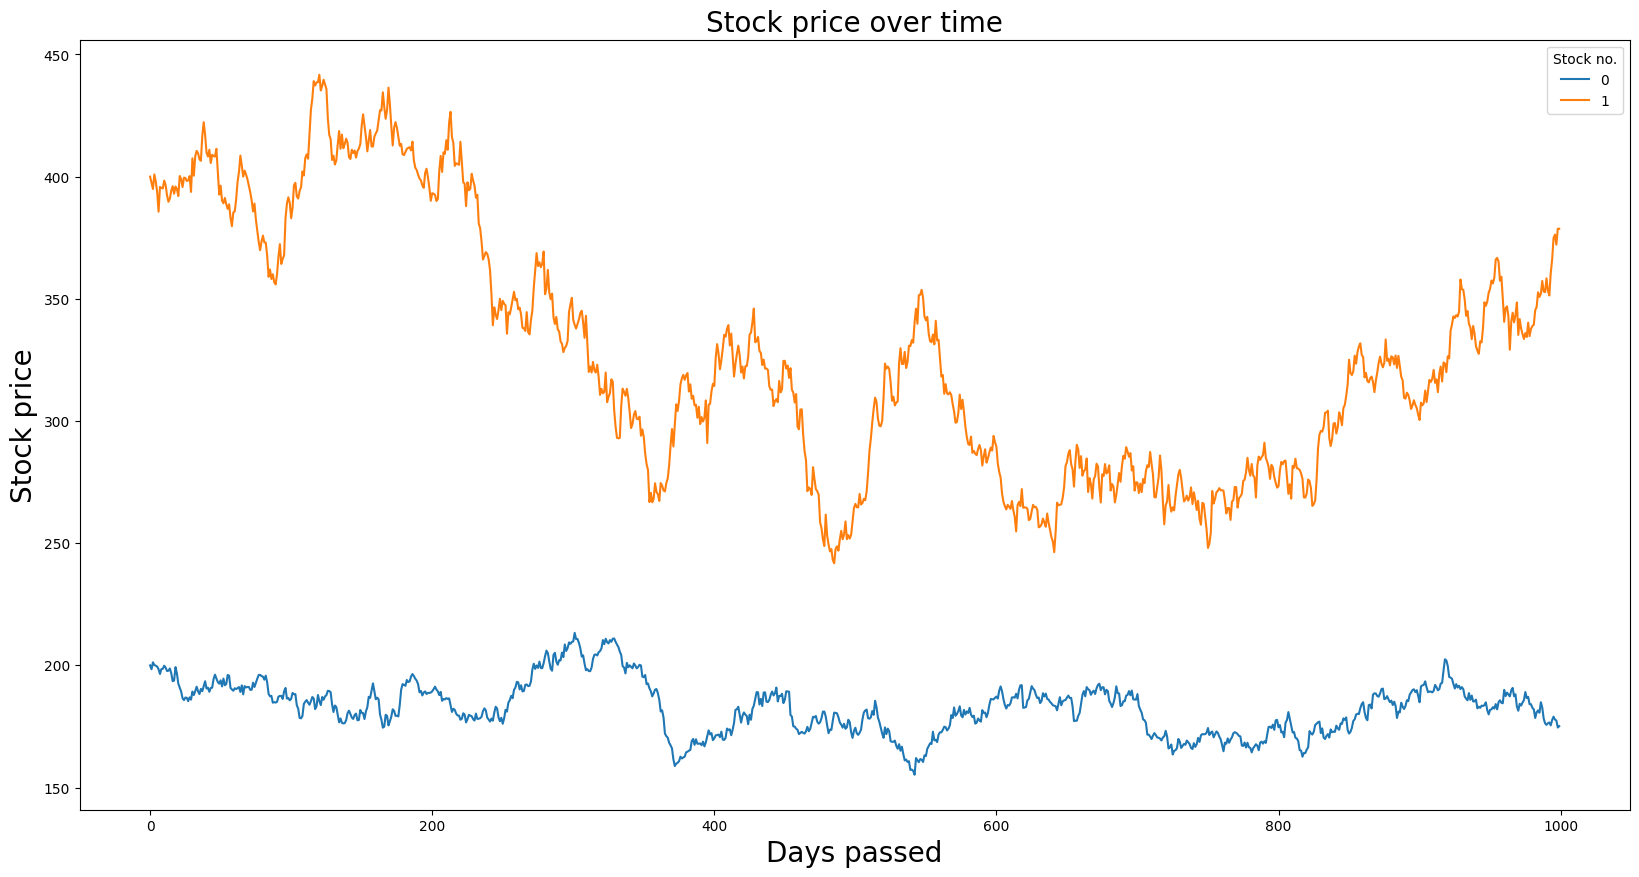

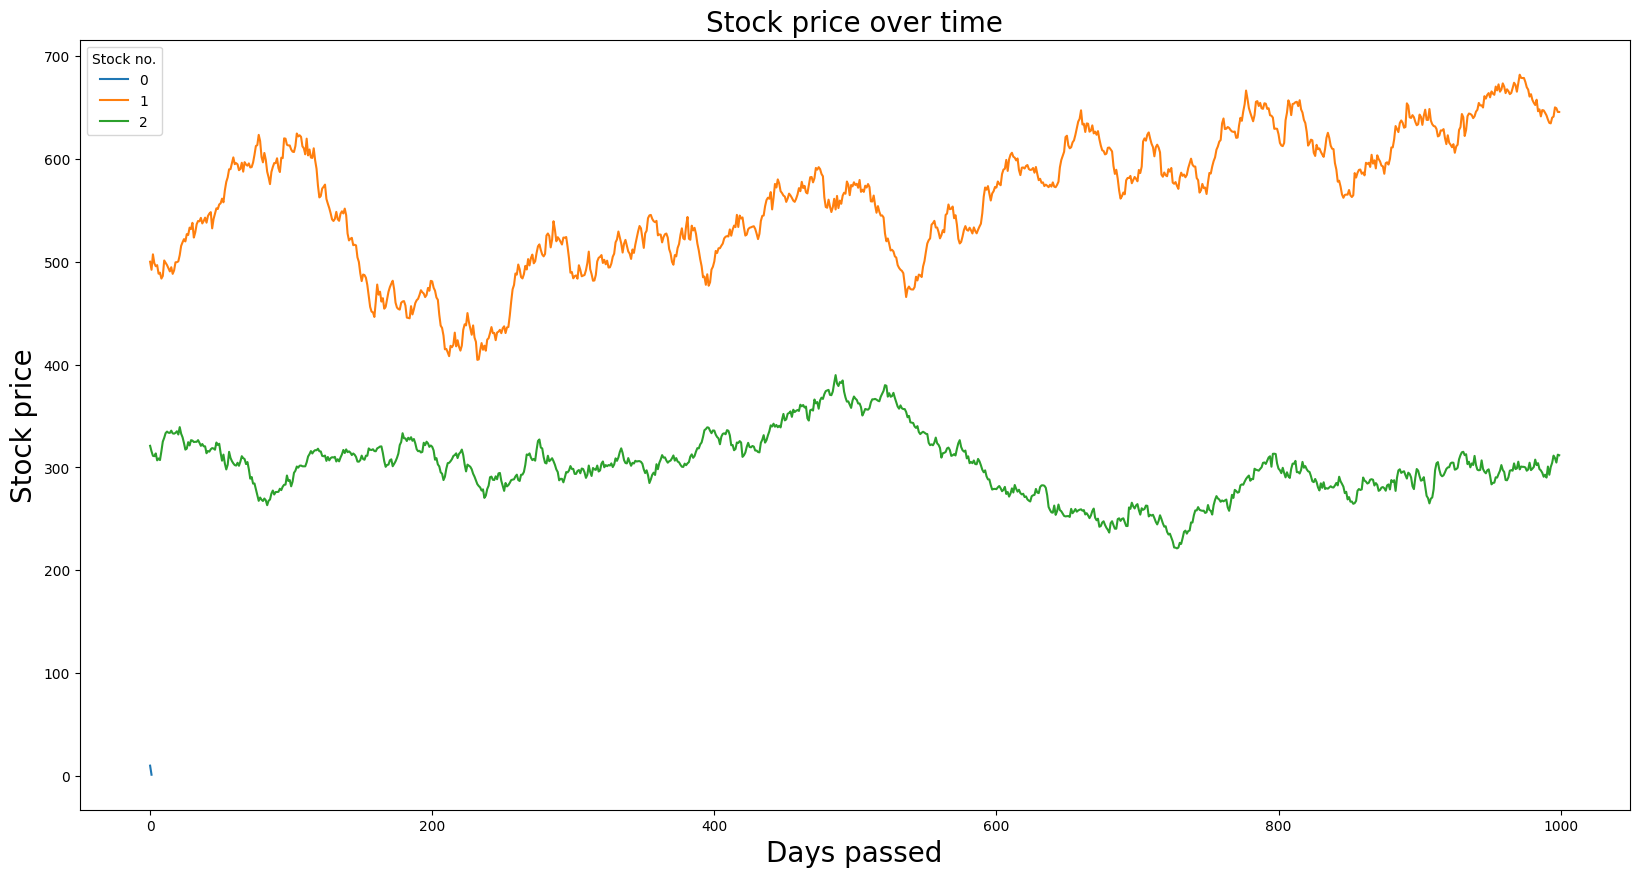

In [ ]:
import trading.data as data

import matplotlib.pyplot as plt

# Make some data
p0 = [200, 400]
v = [1, 2.5]

N = len(p0)

stock_prices = data.generate_stock_price(days=1000, initial_price=p0, volatility=v)

time_period = list(range(len(stock_prices[:,0])))

plt.figure(figsize=(20,10))

for stock in range(N):   # made more robust to change of inputs
    plt.plot(time_period, stock_prices[:,stock], label = stock)


plt.legend(title = 'Stock no.')
plt.xlabel('Days passed', fontsize = 20)
plt.ylabel('Stock price', fontsize = 20)
plt.title('Stock price over time', fontsize = 20)
plt.show()

# Test when company fails and for a different number of companies
# Should see the stock price stops being plotted for the failed company after failure

p0 = [10, 500, 321]
v = [5, 3, 2]

N = len(p0)

stock_prices = data.generate_stock_price(days=1000, initial_price=p0, volatility=v)

time_period = list(range(len(stock_prices[:,0])))

plt.figure(figsize=(20,10))

for stock in range(N):   # made more robust to change of inputs
    plt.plot(time_period, stock_prices[:,stock], label = stock)


plt.legend(title = 'Stock no.')
plt.xlabel('Days passed', fontsize = 20)
plt.ylabel('Stock price', fontsize = 20)
plt.title('Stock price over time', fontsize = 20)
plt.show()

---
Now, use simulation data to test different trading strategies. The goal is to:

1. Design a **trading strategy** -- an algorithm which will make buying or selling decisions based on certain rules, given the price data up to the current date.
2. **Deploy it** over 5 years of simulation data. We will need to write code to actually execute the buying and selling, and log the transactions.
3. Evaluate its **performance** over 5 years (in terms of profit made), and how it depends on different factors.

For all functions which have a precise specification, the **docstring** will already be written for each function you need to write, which will describe what the function needs to do, what input arguments it takes, and what output values it returns. When the assignment is released, all function definitions will only have the `pass` command -- which is just telling Python to do nothing. Remove the `pass` command and replace it with your code to define each function.

The file `stock_data_5y.txt` contains data generated using the procedure from Task 1, for 20 different stocks over 5 years. The first row indicates the value used for volatility when the data was generated.

---

### 2.0. Retrieve data

🚩 In the `data.py` module, write a function `get_data()` to either generate simulation data (using the code from Task 1) or read pre-computed data from a file into a Numpy array `sim_data`. The user should be able to choose if they want to generate new data or read the data file.

### 2.1. Transaction processing

Let's start by writing functions which will actually do the work of buying and selling stock, updating our portfolio, and logging transactions in a ledger.

Write functions in the `process.py` module for this part.

#### Log transactions in a ledger

🚩 Every time we perform a transaction, we need to add a record of it to the ledger file. Write a function `log_transaction()` to log a transaction in a file `ledger.txt`.

#### Buying and selling

To keep track of how many shares we currently own for each stock, we will use a list `portfolio` of length `N` (where `N` is the number of different stocks available in the simulation), where each element is an integer indicating the number of shares we own for that stock.

For example, if there are 5 different stocks available, and we own 4 shares of stock `0` and 2 shares of stock `3`, then the list `portfolio` should be `[4, 0, 0, 2, 0]`.

Let's start with some simplifying assumptions:
- We will only hold a [*long position*](https://www.investopedia.com/ask/answers/100314/whats-difference-between-long-and-short-position-market.asp) -- this means that we will only be able to sell shares that we have already bought.
- Whenever we decide that it's a good time to sell shares for a given stock (based on our strategy), we'll sell *all* our shares at once.
- We have infinite money to spend (wouldn't that be nice? 😊)

🚩 Write a function `buy()` to purchase shares from a given company, using an allocated amount of money, and a function `sell()` to sell all the shares you own for a given stock. Both these functions should read and update the list `portfolio` **in-place** when you make a purchase or sell stock, as well as call `log_transaction()` to record the transaction in the ledger.

#### Create a portfolio

🚩 Write a function `create_portfolio()` which creates a portfolio with size `N`, calling the function `buy()` to purchase some shares on different stocks on the first day of the simulation.

The way we decide how many shares to buy of each stock on day 0 will be a part of our strategy later on.

#### Pause for testing

Before moving any further, it's time to do some testing to make sure all these parts are working together well.

🚩 In the code cell below, import your `data` and `process` modules.
- Use your function `get_data()` to read the 5 columns of `stock_data_5y.txt` with initial prices closest to 100, 120, 400, 250, and 300.
- Use your function `create_portfolio()` to create a test portfolio by buying shares for these 5 stocks, allocating 5000 to each stock, with fees of 20 per transaction.

You should obtain the following portfolio:
```
[49, 38, 12, 19, 15]
```
and you should see this data in `ledger.txt`:
```
buy,0,0,49,100.00,-4920.00
buy,0,1,38,130.00,-4960.00
buy,0,2,12,400.00,-4820.00
buy,0,3,19,260.00,-4960.00
buy,0,4,15,330.00,-4970.00
```

You should also check that this works when you generate data from scratch instead of reading it from the file.

In [11]:
import trading.data as data
import trading.process as process

sim_data = data.get_data(initial_price = [100,120,400,250,300])

process.create_portfolio(5000, sim_data, 20, ledger_file = 'ledger.txt')

Found data with initial prices [np.float64(100.0), np.float64(130.0), np.float64(400.0), np.float64(260.0), np.float64(330.0)] and volatilities [np.float64(3.4), np.float64(0.6), np.float64(4.6), np.float64(1.6), np.float64(4.2)].


array([49., 38., 12., 19., 15.])

In [ ]:
import trading.data as data
import trading.process as process

# Now test with generated data 

sim_data = data.get_data(method='generate', initial_price=[150, 250], volatility=[1.8, 3.2])

process.create_portfolio(5000, sim_data, 20, ledger_file = 'ledger.txt')

array([33., 19.])

### 2.2. Indicators

To implement a trading strategy, we will need to compute some **indicators** from the data over time, up to a given date. These indicators will help us make decisions about what to buy and sell, and when.

Remember that at any date you compute these indicators, you should only use **past** data.

Your functions for this part should go in the `indicators.py` module.

#### Moving averages

A moving average is simply an average (sometimes weighted) of the share price, calculated over a number of days. For example, the 7-day moving average at a given date is the average price over the 7 days leading up to the date. The moving average essentially smoothes out the high-frequency noise in the daily price data, allowing to see the more long-term variations.

🚩 Write a function `moving_average()` which calculates the $n$-day moving average for a stock over time. Your function should also be able to calculate weighted moving averages, if given a vector of weights.

#### Oscillators

An oscillator is a signal which generally indicates how well the price is doing today, relatively to how well it has been doing overall for the past $n$ days. Oscillators are a relative measure, given as a percentage. Two widely-used oscillators are the **stochastic oscillator** and the **relative strength index (RSI)**. When they reach certain thresholds, they can be used to make buying or selling decisions.

To calculate the level of the stochastic oscillator on a given day:

1. Find the highest and lowest prices over the past $n$ days.
2. Compute the difference between today's price and the lowest price, call it $\Delta$.
3. Compute the difference between the highest price and the lowest price, call it $\Delta_{\text{max}}$.
4. The level of the oscillator on this day is the ratio $\frac{\Delta}{\Delta_{\text{max}}}$.

To calculate the level of the RSI on a given day:

1. Calculate all the price differences on **consecutive days** over the past $n$ days.
2. Separate the positive differences (i.e. the price increased from one day to the next) from the negative differences (the price decreased from one day to the next).
3. Calculate the average of all the positive differences, and the absolute value of the average of all the negative differences.
4. Calculate the ratio between these 2 averages (positive/negative). Call this $RS$ (the relative strength).
5. The RSI on this day is given by $1 - \frac{1}{1+RS}$.

🚩 Write a function `oscillator()` which can calculate either the stochastic oscillator or the RSI over time (as indicated by the user), using a period of $n$ days.

---
### 2.3. Trading strategy

Now that we have all our tools ready to trade, it's time to deploy some trading strategies!

All your functions for this part should go in the `strategy.py` module. Note that since you will use functions from your `process.py` module, you should import it at the start of `strategy.py`. Since it's in the same folder, you don't need the `trading.` prefix there:
```python
import process as proc
```

There is a bit more freedom for you here in how you implement these functions, so we will only provide the docstring for `random()`, to give you an idea of what essential input data you'll need.

With every strategy:
- we start a new ledger file,
- we start with creating a portfolio on day 0 and invest some amount **equally** between all available stocks,
- we invest this same amount any time we buy shares,
- we finish with selling all remaining stock on the last day.

#### The "feeling lucky" strategy

The first "strategy" we'll try is the **random strategy**: we're going to decide randomly whether to buy or sell shares for each stock, and do this at regular time intervals.

🚩 Write a function `random()` which periodically, for each stock, decides whether to buy more shares, do nothing, or sell all your shares.

#### Crossing averages

This strategy involves computing 2 different moving averages over time, one "slow" and one "fast". Periods of 50 days and 200 days are often used, for instance. Since the fast moving average (FMA) will change more quickly than the slow moving average (SMA) when the share price changes, one could interpret the following:

- When the FMA crosses the SMA from below, then the share price is starting to rise significantly, and it's a good time to buy shares.
- When the FMA crosses the SMA from above, then the share price is starting to lower significantly, and it's a good time to sell shares before the price gets too low.

🚩 Write a function `crossing_averages()` which finds the crossing points between a SMA with period $n$ and a FMA with period $m$ to make buying or selling decisions.

#### Momentum trading using oscillators

Oscillators can help us guess if the price of a share is currently overvalued (*overbought*) or undervalued (*oversold*). Generally:
- the price is considered overvalued when the oscillator is above a threshold of 0.7 to 0.8 (good time to sell).
- the price is considered undervalued when the oscillator is below a threshold of 0.2 to 0.3 (good time to buy).

🚩 Write a function `momentum()` which uses a given oscillator (stochastic or RSI) with period $n$ to make buying or selling decisions, depending on a low threshold and a high threshold.

You should implement a minimum cool-down period after buying or selling, before making another transaction -- otherwise, if the oscillator crosses a threshold and stays beyond it for some time, you could end up buying shares every day for a while!

Alternatively, you could also wait until the oscillator has remained beyond a threshold for a few days before deciding to buy or sell.

#### Time for testing!

🚩 Test your functions in the code cell below, using data for one stock and a fairly short period of time (instead of 5 years). Run each of your functions on the data, plot relevant indicators, and check the ledger to see whether your strategies have performed the required transactions correctly.

In [ ]:
# my own testing:
import numpy as np
import trading.data as data
import trading.process as process
import trading.indicators as indic
import trading.strategy as strat

# Want to check that the strategy functions actually work, by checking graphically.

# Read data with given initial prices
sim_data = data.get_data(initial_price = [150,451,300,120], volatility = [10, 1, 50, 3])

# Select first year of data
stock_prices = sim_data

# Select data for one stock
stock_price = stock_prices[:,1]

strat.random(stock_prices, period=10, amount=5000, fees=20, ledger='ledger_random.txt')


Since plotting data over time won't be very useful for random strategy we instead check in the ledger that purchases or sales have been made periodically and not on days in between. We see that this is the case, and the only exception is when all remaining stocks are sold on the final day. Therefore, we can claim that this strategy has been implemented correctly as these points act as evidence to this claim.  

Found data with initial prices [np.float64(150.0), np.float64(450.0), np.float64(220.0), np.float64(100.0), np.float64(360.0)] and volatilities [np.float64(5.4), np.float64(2.8), np.float64(0.2), np.float64(3.4), np.float64(3.8)]. Input argument volatility ignored.
Crossing at day: 217
Crossing at day: 317
Crossing at day: 351
Crossing at day: 412
Crossing at day: 456
Crossing at day: 711
Crossing at day: 750
Crossing at day: 820
Crossing at day: 928
Crossing at day: 1031
Crossing at day: 1048
Crossing at day: 1113
Crossing at day: 1309
Crossing at day: 1458
Crossing at day: 1638
Crossing at day: 1763


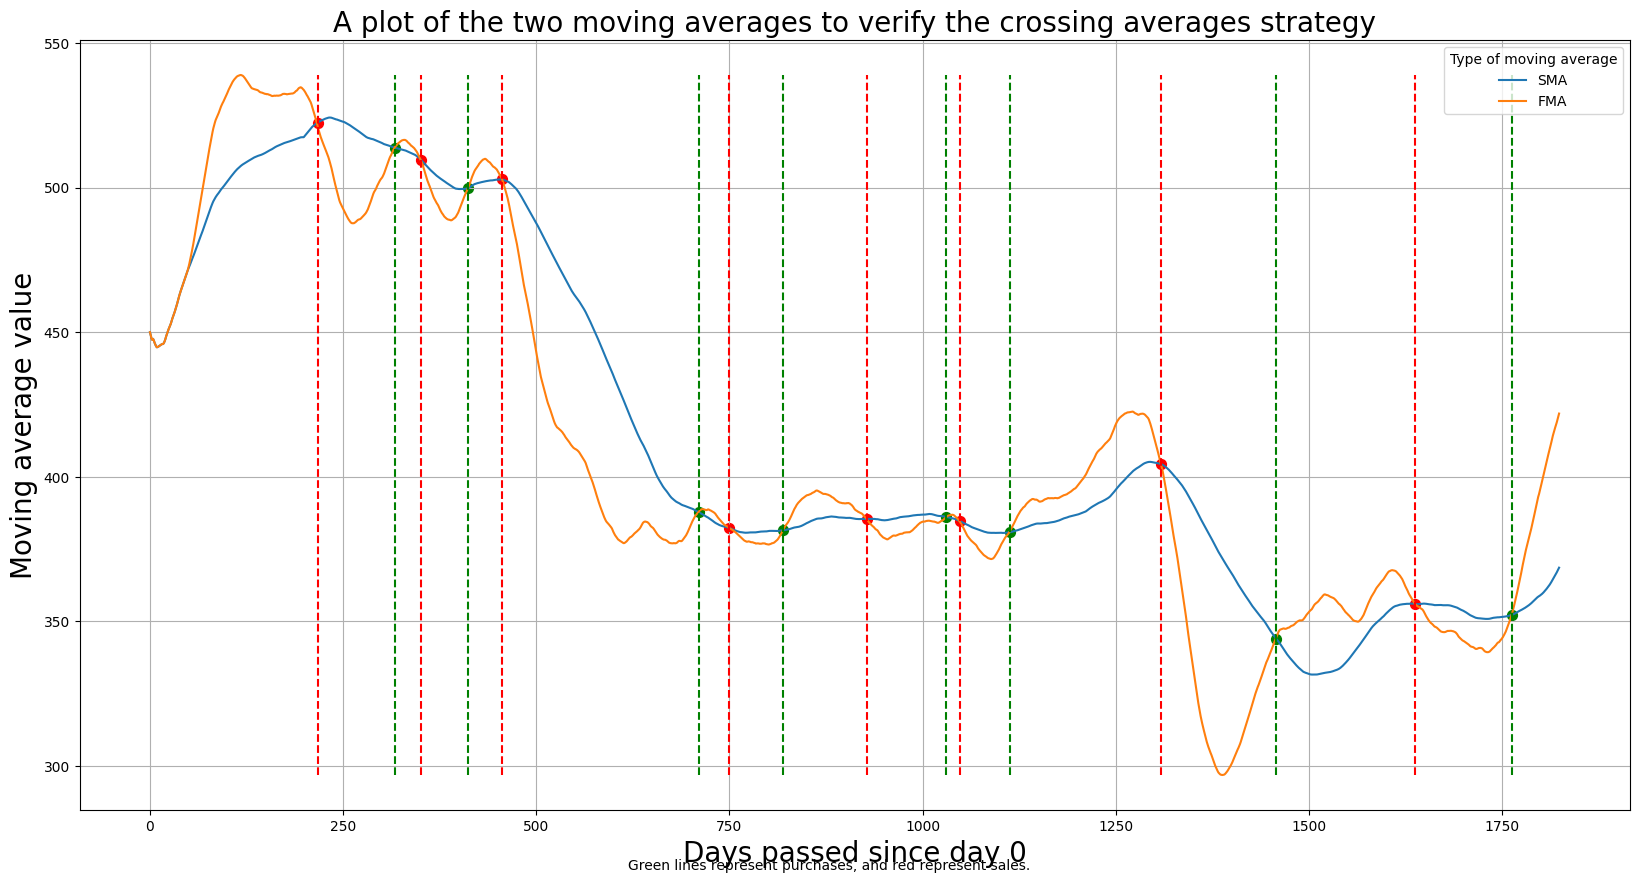

In [ ]:
# Repeat testing with data for crossing average strategy
import trading.data as data
import trading.process as process
import trading.strategy as strat
import trading.performance as performance
import trading.indicators as indic

import matplotlib.pyplot as plt

# Use same stock prices as above to compare the strategies
sim_data = data.get_data(initial_price = [150, 451, 220, 10, 360], volatility = [3, 7, 1, 4, 7])
stock_prices = sim_data

# Choose price of stock 1 over time
stock_price = stock_prices[:,1] 


strat.crossing_averages(stock_prices, n=200, m=50, weights=[], amount=5000, fees=20, ledger='ledger_crossing_points.txt')

# Get the two moving averages
SMA = indic.moving_average(stock_price, n=200, weights = [])
FMA = indic.moving_average(stock_price, n=50, weights = [])

# Set x-axis
no_of_days = (len(stock_price))
day_no = list(range(no_of_days))

fig = plt.figure(figsize=(20,10))
txt = 'Green lines represent purchases, and red represent sales.'
fig.text(.5, .05, txt, ha='center')
plt.plot(day_no, SMA, label = 'SMA')
plt.plot(day_no, FMA, label = 'FMA')
plt.legend(title = 'Type of moving average')
plt.grid()
plt.title('A plot of the two moving averages to verify the crossing averages strategy', fontsize = 20)
plt.xlabel('Days passed since day 0', fontsize = 20)
plt.ylabel('Moving average value', fontsize = 20)

import numpy as np

## Difference between fast and slow moving averages
diff = FMA - SMA

# Ignore startup period until long MA is established
start_idx = 200   # or max(n, m)
# This means the crossing at day 50 is not detected, but this is expected as the long MA is not established until day 200
# A 200-day SMA is not fully meaningful until enough data exists. Before roughly day 200, the 200-day average may be incomplete, early values are unstable and fast and slow averages can cluster artificially.


# Slice usable region
usable = diff[start_idx:].copy()

# Remove NaNs
usable[np.isnan(usable)] = 0

# Replace zeros with previous nonzero sign
signs = np.sign(usable)

for i in range(1, len(signs)):
    if signs[i] == 0:
        signs[i] = signs[i-1]

# Find sign flips
crossings = np.where(np.diff(signs) != 0)[0] + 1 + start_idx

for i in crossings:

    # Buy = fast MA crosses above slow MA
    if diff[i] > diff[i-1]:
        color = 'g'
        label = 'purchase'
    else:
        color = 'r'
        label = 'sale'

    plt.scatter(i, SMA[i], marker='o', s=50, color=color)

    plt.vlines(
        x=i,
        ymin=min(np.nanmin(SMA), np.nanmin(FMA)),
        ymax=max(np.nanmax(SMA), np.nanmax(FMA)),
        colors=color,
        linestyles='dashed'
    )

    print("Crossing at day:", i)

I have plotted the intersections of the SMA and FMA for stock 1 over the five years (I chose this time frame since this strategy makes transactions relatively infreqeuntly and hence a large timeframe does not crowd the plot). This verifies that the data plotted in the ledger is correct, since every purchase/sale represented in the above graph is logged in the ledger. 

Note, there is a problem with my plotting since the graph is not indicating the crossing points that correspond to purchases at day 50 and 711, and a sale at day 217. However, this is not a major issue since the crossing points are still there (even if they are not highlighted), and their corresponding transactions are logged in the ledger. This is a minor bug and is commented appropriately in the code cell above. Perhaps a code review from a peer would be a good way to solve this bug, since another approach to finding the intersections of two lines would be useful. 

In [ ]:
import trading.data as data
import trading.process as process
import trading.strategy as strat
import trading.performance as performance
import trading.indicators as indic

# Read data with given initial prices
sim_data = data.get_data(initial_price = [150,451], volatility = [10, 1])

# Select first 30 days of data
stock_prices = sim_data[:30] 

# Get list of days 
days = list(range(30))
no_of_days = len(days)

# Simulate the strategy
strat.momentum(stock_prices, osc_type='stochastic', n=7, overvalued_bound=0.7, undervalued_bound=0.3, cool_down=3, amount=5000, fees=20, ledger='ledger_momentum.txt')

# Plot the oscillators for each stock individually
stock_price = stock_prices[:,0]   # we selected stock price for stock number 0

import matplotlib.pyplot as plt

overvalued_bound=0.7 
undervalued_bound=0.3

f, (ax1, ax2) = plt.subplots(2,1,sharex=True,figsize=(8,12),
        constrained_layout=True)
im1 = ax1.plot(days, stock_price)

ax1.set_ylabel('Share price')


im2 = ax2.bar(days, indic.oscillator(stock_price, n=7, osc_type='stochastic'), linewidth=3 )

ax2.plot(days, [overvalued_bound]*no_of_days, color = 'r')
ax2.plot(days, [undervalued_bound]*no_of_days, color = 'r')

ax2.set_ylabel('Oscillator value')
ax2.set_xlabel('Days')

f.suptitle('Comparing stock price and stochastic oscillator value for stock 0', fontsize=16)
plt.ioff()

# Plot the oscillators for each stock individually
stock_price = stock_prices[:,1]   # we selected stock price for stock number 0

f, (ax1, ax2) = plt.subplots(2,1,sharex=True,figsize=(8,12),
        constrained_layout=True)
im1 = ax1.plot(days, stock_price, color = 'g')

ax1.set_ylabel('Share price')


im2 = ax2.bar(days, indic.oscillator(stock_price, n=7, osc_type='stochastic'), linewidth=3 ,color =  'g')

ax2.plot(days, [overvalued_bound]*no_of_days, color = 'r')
ax2.plot(days, [undervalued_bound]*no_of_days, color = 'r')

ax2.set_ylabel('Oscillator value')
ax2.set_xlabel('Days')

f.suptitle('Comparing stock price and stochastic oscillator value for stock 1', fontsize=16)
plt.ioff()


Since an oscillator is a signal which generally indicates how well the price is doing today, relative to how well it has been doing overall for the past $n$ days, I have plotted stock price over the period as well as the oscillator values. This has allowed me to conclude that the oscillator values have been corrected calculated, since when the stock price increases over a period the oscillator values are large, and the opposite is true when stock prices decrease. Additionally, the oscillator values range from 0 to 1 as expected. 

Since we have chosen a cool down period of 3 days, we would expect to only make buying or selling decisions after the stock price has been beyond one of the threshold values for this number of days. Looking at stock 0, this would imply that we would buy on days 11, 14, 17 and 20 and only sell on day 29. These transactions agree with what appears in the ledger.

For stock 1, purchases are expected on day 3 and 7, as well as a sale on day 13 (no more sales after this as well sell all stocks on this date and then buy no more). This matches the ledger, and hence these plots provide evidence to my claim that I have correctly implemented the strategy.

I will now test my code for the strategy with an RSI oscillator.

In [ ]:
import trading.data as data
import trading.process as process
import trading.strategy as strat
import trading.performance as performance
import trading.indicators as indic

# Read data with given initial prices
sim_data = data.get_data(initial_price = [150,451], volatility = [10, 1])

# Select first 30 days of data
stock_prices = sim_data[:30] 

# Get list of days 
days = list(range(30))
no_of_days = len(days)

# Simulate the strategy
strat.momentum(stock_prices, osc_type='RSI', n=7, overvalued_bound=0.7, undervalued_bound=0.3, cool_down=3, amount=5000, fees=20, ledger='ledger_momentum.txt')

# Plot the oscillators for each stock individually
stock_price = stock_prices[:,0]   # we selected stock price for stock number 0

import matplotlib.pyplot as plt

overvalued_bound=0.7 
undervalued_bound=0.3

f, (ax1, ax2) = plt.subplots(2,1,sharex=True,figsize=(8,12),
        constrained_layout=True)
im1 = ax1.plot(days, stock_price)

ax1.set_ylabel('Share price')


im2 = ax2.bar(days, indic.oscillator(stock_price, n=7, osc_type='RSI'), linewidth=3 )

ax2.plot(days, [overvalued_bound]*no_of_days, color = 'r')
ax2.plot(days, [undervalued_bound]*no_of_days, color = 'r')

ax2.set_ylabel('Oscillator value')
ax2.set_xlabel('Days')

f.suptitle('Comparing stock price and RSI oscillator value for stock 0', fontsize=16)
plt.ioff()

# Plot the oscillators for each stock individually
stock_price = stock_prices[:,1]   # we selected stock price for stock number 0

f, (ax1, ax2) = plt.subplots(2,1,sharex=True,figsize=(8,12),
        constrained_layout=True)
im1 = ax1.plot(days, stock_price, color = 'g')

ax1.set_ylabel('Share price')


im2 = ax2.bar(days, indic.oscillator(stock_price, n=7, osc_type='RSI'), linewidth=3 ,color =  'g')

ax2.plot(days, [overvalued_bound]*no_of_days, color = 'r')
ax2.plot(days, [undervalued_bound]*no_of_days, color = 'r')

ax2.set_ylabel('Oscillator value')
ax2.set_xlabel('Days')

f.suptitle('Comparing stock price and RSI oscillator value for stock 1', fontsize=16)
plt.ioff()

Again, these plots demonstrate that my strategy seems to have been implemented correctly. 

For stock 0, the oscillator value never remains above the upper threshold for a period of 3 days. Hence there should be no sales of stock 0 made until all stocks are sold on the final day. Further, the only purchase can be expected on day 22 and these predictions align with the results of the ledger. 

For stock 1, we predict a purchase of stocks on day 3 and a sale on day 14. Again, these predictions match the ledger. Note that, while the value remains above 0.7 for days 18 through 21, we do not own any stocks to sell since no further purchases are made after day 3. Therefore, there are no other sales.


Hence, I have tested all strategies such that they seem to be working correctly. 

---
### 2.4. Evaluation

Now that we've checked that our strategies worked, we can deploy them on lots of data and see how they do. Any functions you write for this part should go in `performance.py`.

#### Getting data from the ledger

The ledger created for each strategy will contain the key information as to how well it has performed.

🚩 Write a function `read_ledger()` which reads out data from a ledger file. Your function should report relevant overall information and display it on the screen in a readable manner, to get a quick glance at how much trading has been performed during the simulation by a given strategy. For example, you could report:
- the total number of transactions performed
- the total amount spent and earned over 5 years
- the overall profit or loss over 5 years
- the state of your portfolio just before the last day
- etc...

Your function should also produce a plot of the amount of money you had over time, starting from zero before buying the first shares. If you made a profit overall, then this graph should be above zero on the last day; if you made a loss, it will be below zero.

#### Run some simulations

🚩 In the code cell below (you can create more if you wish), run simulations using your different strategies.
- Use `get_data()` to read or simulate some data for 1 or more stock(s).
- Then, call 1 or more of your strategies to perform the simulation on the data.
- Finally, use `read_ledger()` to report results after each simulation.

Here are some of the ways you could evaluate your strategies -- you should try at least a couple of these. If you have other ideas for investigation, feel free to explore them too. You should plot and display any relevant data which helps the reader understand your findings.
- Produce a large, clearly labelled plot, showing the share price of one stock over time, the 2 moving averages used with `crossing_averages()` on the same graph, and the 2 different oscillators used with `momentum()` on a smaller graph below, with the time axes aligned. Find a way to indicate on the plots where the purchases and sales were made by each strategy.
- Find (or generate) data which seems to have a relatively strong upwards or downwards trend, and test your strategies on this data.
- Generate data for at least 20 stocks, all with the same initial price and volatility. This will allow you to more reliably evaluate the performance of a given strategy, by essentially repeating the experiment with the same parameters. How often does each strategy "win" (i.e. beat the other strategies in terms of final profit)? Can you find a measure of the reliability of each strategy?
- When operating on the same data, do the strategies (apart from `random()`) generally make purchases and sales at similar times? Can you explain why/why not?
- Experiment with different volatilities -- do certain strategies seem to perform better or worse for more volatile stocks?
- Experiment with different periods for the moving averages and the oscillators, and different decision thresholds or cool-down periods.

We will begin our evaluation by comparison of transactions made by the crossing averages and momentum strategies with one stock price, read from the stock data.

In [ ]:
# Note: before running each simulation followed with the function read_ledger
# we must delete any previously existing ledgers with the same name since they
# will contain prexisting information.

In [ ]:
import trading.data as data
import trading.process as process
import trading.strategy as strat
import trading.performance as performance

stock_prices = data.get_data(initial_price = [100, 200, 300])

# Implement random strategy
strat.random(stock_prices, period=7, amount=5000, fees=20, ledger='ledger_random.txt')
# Read ledger
performance.read_ledger('ledger_random.txt')

      

In [ ]:
# Implement momentum strategy
strat.momentum(stock_prices, osc_type='stochastic', n=7, overvalued_bound=0.7, undervalued_bound=0.3, cool_down=3, amount=5000, fees=20, ledger='ledger_momentum.txt')
# Read ledger
performance.read_ledger('ledger_momentum.txt')


In [ ]:
# Implement crossing points strategy
strat.crossing_averages(stock_prices, n=200, m=50, weights=[], amount=5000, fees=20, ledger='ledger_crossing_points.txt')

# Read ledger
performance.read_ledger('ledger_crossing_points.txt')


Running each of these strategies and calling the function `read_ledger()` after allows us to conclude that the function has been defined properly since the results printed in the notebook correspond to the results recorded in the ledger. 

Running the random strategy for this data tends to either give a large profit at the end of simulation which beats the other strategies, or a massive loss. Therefore, this is a very unstable strategy and, as hinted at by the brief, should only be used if you are 'feeling lucky'!

In this case, the momentum strategy produces a greater final profit and is hence the better choice of strategy. 

Next, I wanted to explore the transactions made by the crossing averages strategy and compare the dates of these transactions with the values of the stochastic oscillator at this time. 

In [ ]:
import trading.data as data
import trading.process as process
import trading.strategy as strat
import trading.performance as performance
import trading.indicators as indic

# Read data with given initial prices
sim_data = data.get_data(initial_price = [451], volatility = [1])

# Select first 30 days of data
stock_prices = sim_data


# Plot the oscillators for each stock individually
stock_price = stock_prices[:,0]   # we selected stock price for stock number 0

import matplotlib.pyplot as plt

overvalued_bound=0.7 
undervalued_bound=0.3

# Get the two moving averages
SMA = indic.moving_average(stock_price, n=200, weights = [])
FMA = indic.moving_average(stock_price, n=50, weights = [])

# Set x-axis
no_of_days = (len(stock_price))
day_no = list(range(no_of_days))


f, (ax1, ax2) = plt.subplots(2,1,sharex=True,figsize=(10,20),
        constrained_layout=True)
ax1.plot(day_no, SMA, label = 'SMA')
ax1.plot(day_no, FMA, label = 'FMA')

ax1.set_ylabel('Value of Moving Average')
ax1.legend()

intersection = - SMA + FMA

purchases = []
sales = []
for i in range(no_of_days):
    if intersection[i-1] * intersection[i] < 0:
        # print(i) here returns only 317 and 351
        # bug since it should also return 50 and 217
        if SMA[i-1] < FMA[i-1]:
            ax1.scatter(i, SMA[i], marker='o', s = 50, color='r', label = 'sale') # have checked these match w ledger
            ax1.vlines(x=i, ymin=200, ymax=max(max(SMA), max(FMA)), colors='r', linestyles='dashed', label=f'{i}')
            sales.append(i)
        else:
            purchases.append(i)
            ax1.scatter(i, SMA[i], marker='o', s = 50, color='g', label = 'purchase') # have checked these match w ledger
            ax1.vlines(x=i, ymin=200, ymax=max(max(SMA), max(FMA)), colors='g', linestyles='dashed', label=f'{i}')
    else:
        pass

im2 = ax2.bar(day_no, indic.oscillator(stock_price, n=7, osc_type='stochastic'), linewidth=3 )

ax2.plot(day_no, [overvalued_bound]*no_of_days, color = 'r')
ax2.plot(day_no, [undervalued_bound]*no_of_days, color = 'r')

ax2.set_ylabel('Oscillator value')
ax2.set_xlabel('Days')

for sale in sales:
    ax2.vlines(x=sale, ymin=0, ymax=1, colors='r', linestyles='dashed', label=f'{sale}')

for buy in purchases:
    ax2.vlines(x=buy, ymin=0, ymax=1, colors='g', linestyles='dashed', label=f'{buy}')

f.suptitle('Comparing transactions made by crossing averages with oscillator values', fontsize=16)

txt = 'Green lines represent purchases, and red represent sales.'
f.text(.5,-0.01, txt, ha='center')

plt.ioff()

strat.momentum(stock_prices, osc_type='stochastic', n=10, overvalued_bound=0.7, undervalued_bound=0.3, cool_down=7, amount=5000, fees=20, ledger='ledger_momentum.txt')

Since the momentum strategy makes many more transactions than the crossing averages strategy in this case, I decided to plot the purchases made by my crossing averages strategy on my oscillator value plot. In this way, you can see that in the days leading up to a purchase the oscillator value is relatively small on average which is what we would expect. Further, the graph seems to show that the values of the oscillator leading up to a sale average above the upper threshold. This is again what we would expect and, hence, we can conclude that these strategies support one another.

However, I would argue that this claim needs to be explored in more detail. Hence, I shall now compare the transactions made by the crossing averages strategy with the momentum strategy (for oscillator types RSI and stochastic). First, I will choose some relatively choppy data by getting data with a relatively high volatility. 

In [ ]:
import trading.data as data
import trading.process as process
import trading.strategy as strat
import trading.performance as performance
import trading.indicators as indic

import matplotlib.pyplot as plt


# Read stock_prices from specified (relatively high) volatility
sim_data = data.get_data(volatility = [5])
stock_prices = sim_data[:500] # Get first 500 days of data

# Get the stock price as a list
stock_price = stock_prices[:, 0]

# Run the strategies such that we have the information recorded in the ledger
strat.crossing_averages(stock_prices, n=200, m=50, weights=[], amount=5000, fees=20, ledger='ledger_crossing_points.txt')

strat.momentum(stock_prices, osc_type='stochastic', n=10, overvalued_bound=0.7, undervalued_bound=0.3, cool_down=5, amount=5000, fees=20, ledger='ledger_momentum.txt')


# Note, we have set cool down period as 5 days and the oscillator period as 10 days

# Get data to plot
# Get the day range as a list
day_no = list(range(len(stock_price)))


# Get the two moving averages to plot on axes above
SMA = indic.moving_average(stock_price, n=200, weights = [])
FMA = indic.moving_average(stock_price, n=50, weights = [])

# Get the oscillator values to plot on axes underneath
osc_stoch = indic.oscillator(stock_price, n=10, osc_type='stochastic')
osc_RSI = indic.oscillator(stock_price, n=10, osc_type='RSI')

# Set the thresholds for momentum
overvalued_bound=0.7 
undervalued_bound=0.3

fig, (ax1, ax2, ax3) = plt.subplots(3,1,sharex=True,figsize=(10,20),
        constrained_layout=True)
fig.suptitle('Comparing transactions made with crossing averages and momentum strategies')
ax1.plot(day_no, SMA, label = 'SMA')
ax1.plot(day_no, FMA, label = 'FMA')
ax1.set_ylabel('Value of Moving Average')
ax1.legend(title = 'Moving Average')


ax2.plot(day_no, osc_stoch, label = 'stochastic', color = 'black')
ax2.set_ylabel('Value of Stochastic Oscillator')

ax3.plot(day_no, osc_RSI, label = 'RSI', color = 'black')
ax3.set_ylabel('Value of RSI Oscillator')
ax3.set_xlabel('Day')

for purchase1 in [379]:
    ax1.axvline(x=purchase1, color = 'green', linestyle = 'dashed')

for sale1 in [50, 499]:
    ax1.axvline(x=sale1, color = 'red', linestyle = 'dashed')


# Plot transactions from momentum ledger when type is stochastic
for purchase2 in [255, 281, 286, 312, 344, 384, 458, 463, 477, 482, 487, 495, 13, 23, 44, 75, 80, 116, 129, 140, 151, 156, 165, 170, 175, 193, 198, 203, 221, 226, 231,]:
    ax2.axvline(x=purchase2, color = 'green', linestyle = 'dashed')

for sale2 in [5, 58, 90, 244, 270, 301, 356, 396, 468]:
    ax2.axvline(x=sale2, color = 'red', linestyle = 'dashed')
    
# Now plot transactions from momentum ledger when type is RSI
strat.momentum(stock_prices, osc_type='RSI', n=10, overvalued_bound=0.7, undervalued_bound=0.3, cool_down=5, amount=5000, fees=20, ledger='ledger_momentum.txt')
for purchase3 in [77, 287, 484]:
    ax3.axvline(x=purchase3, color = 'green', linestyle = 'dashed')

for sale3 in [5, 375]:
    ax3.axvline(x=sale3, color = 'red', linestyle = 'dashed')

plt.show()

Here, we have plotted the transactions made by the strategies excluding random when operating on the same data. Firstly, we shall note that the momentum strategy with the stochastic oscillator performs transactions far more frequently than the other two strategies plotted. This is because the RSI oscillator value does not go beyond either threshold value anywhere near as often as the stochastic oscillator, and hence transactions are less likely to occur. 

From the graphs, it seems that there is little correlation between strategies for when transactions are made. In fact, looking at graphs 1 and 3 suggests that the crossing averages and momentum strategies are completely opposing when the oscillator type is RSI. Therefore, I would conclude that the best choice of strategy needs careful consideration and will depend on the stock price data being tested. Thus, I will perform further exploration and end my project with a conclusion of my results.

From some research online, I was able to conclude that, since the RSI oscillator measures the speed of fluctuations in prices, it is more useful in markets where stock prices are relatively consistent. Conversely, stochastics are more useful in 'choppy markets'. 

From this research, I will now explore the contrasting behaviours of each oscillator on some relatively consistent data. In order to find a relatively stable stock price, I looked at the volatilities of each stock price recorded and chose the one with the smallest value. 

In [ ]:
# THIS IS A RELATIVELY STEADY STOCK PRICE DATA RESULT

# Choose only the first year of data, otherwise graph is too crowded

import trading.data as data
import trading.process as process
import trading.strategy as strat
import trading.performance as performance
import trading.indicators as indic

import matplotlib.pyplot as plt

sim_data = data.get_data(initial_price = [220])
stock_prices = sim_data[:365]
stock_price = stock_prices[:, 0]

N = len(stock_prices[0])

time_period = list(range(len(stock_prices[:,0])))
no_of_days = len(time_period)

# Get oscillator values
osc_stoch = indic.oscillator(stock_price, n=10, osc_type='stochastic')
osc_RSI = indic.oscillator(stock_price, n=10, osc_type='RSI')

# Set the thresholds for momentum
overvalued_bound=0.7 
undervalued_bound=0.3


fig, (ax1, ax2, ax3) = plt.subplots(3,1,sharex=True,figsize=(10,20),
        constrained_layout=True)
fig.suptitle('Comparing transactions made by each oscillator with the momentum strategy on stable stock data')

for stock in range(N):   # made more robust to change of inputs
    ax1.plot(time_period, stock_prices[:,stock])
ax1.set_ylabel('Stock price', fontsize = 20)

ax2.bar(time_period, osc_stoch)
ax2.plot(time_period, [overvalued_bound]*no_of_days, color = 'r')
ax2.plot(time_period, [undervalued_bound]*no_of_days, color = 'r')
ax2.set_ylabel('Stochastic oscillator value', fontsize = 20)

ax3.bar(time_period, osc_RSI)
ax3.plot(time_period, [overvalued_bound]*no_of_days, color = 'r')
ax3.plot(time_period, [undervalued_bound]*no_of_days, color = 'r')
ax3.set_ylabel('RSI oscillator value', fontsize = 20)

# Plot sales and purchases:
strat.momentum(stock_prices, osc_type='stochastic', n=10, overvalued_bound=0.7, undervalued_bound=0.3, cool_down=5, amount=5000, fees=20, ledger='ledger_momentum.txt')

strat.momentum(stock_prices, osc_type='RSI', n=10, overvalued_bound=0.7, undervalued_bound=0.3, cool_down=5, amount=5000, fees=20, ledger='ledger_momentum.txt')


# Plot transactions from momentum ledger when type is stochastic
for purchase2 in [9, 69, 98, 103, 123, 132, 176, 181, 186, 191, 231, 236, 241, 302, 322, 327, 332, 337, 342, 351, 356, 361 ]:
    ax2.axvline(x=purchase2, color = 'green', linestyle = 'dashed')

for sale2 in [18, 81, 112, 141, 198, 253, 311]:
    ax2.axvline(x=sale2, color = 'red', linestyle = 'dashed')
    
# Now plot transactions from momentum ledger when type is RSI
for purchase3 in [184, 237, 333]:
    ax3.axvline(x=purchase3, color = 'green', linestyle = 'dashed')

for sale3 in [6, 265]:
    ax3.axvline(x=sale3, color = 'red', linestyle = 'dashed')


plt.show()


In [ ]:
# Remember to delete the ledger before running
strat.momentum(stock_prices, osc_type='stochastic', n=10, overvalued_bound=0.7, undervalued_bound=0.3, cool_down=5, amount=5000, fees=20, ledger='ledger_momentum.txt')

performance.read_ledger('ledger_momentum.txt')

In [ ]:
# Remember to delete the ledger before running
strat.momentum(stock_prices, osc_type='RSI', n=10, overvalued_bound=0.7, undervalued_bound=0.3, cool_down=5, amount=5000, fees=20, ledger='ledger_momentum.txt')

performance.read_ledger('ledger_momentum.txt')

The graphs show that purchases and sales are made at similar dates for each type of oscillator, but that the transactions are more frequent for the stochastic oscillator. After reading the ledger for each simulation, we obtain evidence that supports our conclusion since the overall loss for RSI was less than that of stochastic for this relatively stable set of stock prices. Hence, the RSI would be a better choice of strategy here.

***Conclusion***

Within this project, I have looked at a range of strategies for trading stocks given some data pertaining to the stocks (such as initial price or volatility). I explored the dates at which transactions were made by each strategy, and also explored the effect of volatility on how the strategies perform. As a final takeaway thought, one must always be careful when choosing which strategy to implement as each strategy performs differently under different conditions. Overall, there are so many variables to explore that I acknowledge that this project is only an initial insight into such a problem. 

A few points of note within my project:

- I have included comments within my code throughout to explain how I have dealt with exceptions etc. A few examples of such situations are mentioned below.

- When a company fails, I decided to keep the shares of the company in our portfolio. This is because, once a company fails, you cannot sell the stocks and (while they become worthless) I thought it would be a good idea to keep them in the portfolio such that you can determine how much money was wasted on the purchase of these stocks.

- Once a company has failed, if we try to buy or sell any stocks I record the transaction in the ledger with a type 'failed' rather than buy or sell. The stock price is recorded as `nan`, and there are no transaction fees since no transaction actually occurs. I thought it was better than just passing the transaction, since it shows an attempt has been made to perform a transaction but this was impossible. This is a more informative approach. 

- Finally, I added a line to my code to note that, if we do not own any stocks of a company, we cannot sell. 